Importing libraries

In [2]:
import random
random.seed(0)
import json
import os
from zipfile import ZipFile
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mping
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
import glob
from tensorflow.keras.layers import Rescaling

from tensorflow.keras.layers import Conv2D,MaxPooling2D,GlobalAveragePooling2D,Dense,Dropout,BatchNormalization,Flatten

#unzipping the zip files of train,validation and test data

In [3]:
!unzip /content/train-20251204T081958Z-1-001.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/without_mask/without_mask_1536.jpg  
  inflating: train/without_mask/without_mask_590.jpg  
  inflating: train/without_mask/without_mask_3381.jpg  
  inflating: train/without_mask/without_mask_1619.jpg  
  inflating: train/with_mask/with_mask_38.jpg  
  inflating: train/without_mask/without_mask_1748.jpg  
  inflating: train/with_mask/with_mask_217.jpg  
  inflating: train/with_mask/with_mask_1838.jpg  
  inflating: train/with_mask/with_mask_775.jpg  
  inflating: train/without_mask/without_mask_1792.jpg  
  inflating: train/without_mask/without_mask_357.jpg  
  inflating: train/with_mask/with_mask_978.jpg  
  inflating: train/without_mask/without_mask_1098.jpg  
  inflating: train/without_mask/without_mask_2292.jpg  
  inflating: train/without_mask/without_mask_2344.jpg  
  inflating: train/with_mask/with_mask_3656.jpg  
  inflating: train/without_mask/without_mask_2384.jpg  
  inflating: train/with_mask/with_mask_1

In [4]:
!unzip /content/val-20251204T081726Z-1-001.zip

Archive:  /content/val-20251204T081726Z-1-001.zip
  inflating: val/with_mask/with_mask_1718.jpg  
  inflating: val/with_mask/with_mask_583.jpg  
  inflating: val/without_mask/without_mask_2504.jpg  
  inflating: val/with_mask/with_mask_606.jpg  
  inflating: val/with_mask/with_mask_1736.jpg  
  inflating: val/with_mask/with_mask_3664.jpg  
  inflating: val/with_mask/with_mask_3077.jpg  
  inflating: val/with_mask/with_mask_1524.jpg  
  inflating: val/with_mask/with_mask_1563.jpg  
  inflating: val/with_mask/with_mask_2996.jpg  
  inflating: val/with_mask/with_mask_1824.jpg  
  inflating: val/with_mask/with_mask_2552.jpg  
  inflating: val/with_mask/with_mask_433.jpg  
  inflating: val/with_mask/with_mask_3407.jpg  
  inflating: val/with_mask/with_mask_1797.jpg  
  inflating: val/with_mask/with_mask_3003.jpg  
  inflating: val/with_mask/with_mask_327.jpg  
  inflating: val/with_mask/with_mask_2387.jpg  
  inflating: val/with_mask/with_mask_1943.jpg  
  inflating: val/with_mask/with_mask

In [5]:
!unzip /content/test-20251204T081729Z-1-001.zip

Archive:  /content/test-20251204T081729Z-1-001.zip
  inflating: test/without_mask/without_mask_1665.jpg  
  inflating: test/without_mask/without_mask_2147.jpg  
  inflating: test/without_mask/without_mask_2475.jpg  
  inflating: test/without_mask/without_mask_2228.jpg  
  inflating: test/without_mask/without_mask_1297.jpg  
  inflating: test/without_mask/without_mask_733.jpg  
  inflating: test/without_mask/without_mask_2871.jpg  
  inflating: test/with_mask/with_mask_455.jpg  
  inflating: test/without_mask/without_mask_2980.jpg  
  inflating: test/without_mask/without_mask_1176.jpg  
  inflating: test/without_mask/without_mask_2547.jpg  
  inflating: test/with_mask/with_mask_2590.jpg  
  inflating: test/without_mask/without_mask_384.jpg  
  inflating: test/without_mask/without_mask_2922.jpg  
  inflating: test/with_mask/with_mask_1174.jpg  
  inflating: test/without_mask/without_mask_2362.jpg  
  inflating: test/with_mask/with_mask_3655.jpg  
  inflating: test/with_mask/with_mask_121

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory("train/",shuffle=True,seed=123,
                                                       image_size=(224,224),
                                                       batch_size=128)

Found 5287 files belonging to 2 classes.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory("val/",shuffle = True,seed = 123,
                                                     image_size=(224,224),
                                                     batch_size=128)

Found 1510 files belonging to 2 classes.


In [8]:
test_ds = tf.keras.utils.image_dataset_from_directory("test/",shuffle=True,
                                                      seed=123,
                                                      image_size=(224,224),
                                                      batch_size=128)

Found 757 files belonging to 2 classes.


#Data Preprocessing

In [9]:
data_preprocess = Sequential(
    [
        Rescaling(1.0/225)
    ]
)

In [10]:

train_ds = train_ds.map(lambda x, y: (data_preprocess(x), y))
val_ds = val_ds.map(lambda x, y: (data_preprocess(x), y))
test_ds = test_ds.map(lambda x, y: (data_preprocess(x), y))

In [11]:
class_dirs = os.listdir("train/")
class_dirs

['without_mask', 'with_mask']

In [28]:
class_dirs = os.listdir("train/")
image_dict = {} # dict to store image array(key) for every class(value)
count_dict = {} # dict to store count of files(key) for every class(value)

for cls in class_dirs:
    file_paths = glob.glob(f'train/{cls}/*')
    count_dict[cls] = len(file_paths)
    image_path = random.choice(file_paths)
    image_dict[cls] = tf.keras.utils.load_img(image_path)

In [13]:
image_dict

{'without_mask': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=168x299>,
 'with_mask': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=350x354>}

In [14]:
count_dict

{'without_mask': 2679, 'with_mask': 2607}

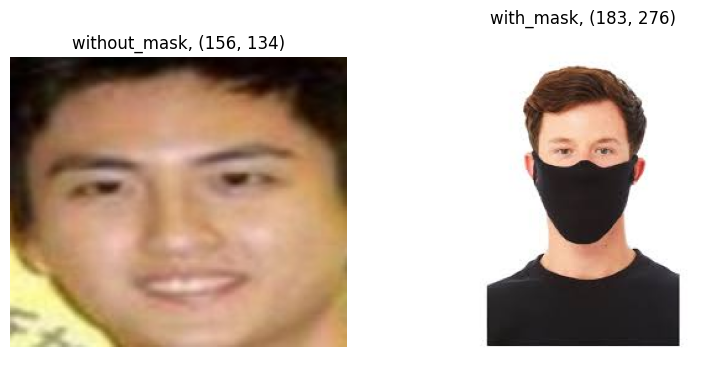

In [29]:
plt.figure(figsize=(20, 15))

for i, (cls,img) in enumerate(image_dict.items()):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f'{cls}, {img.size}')
    plt.axis("off")

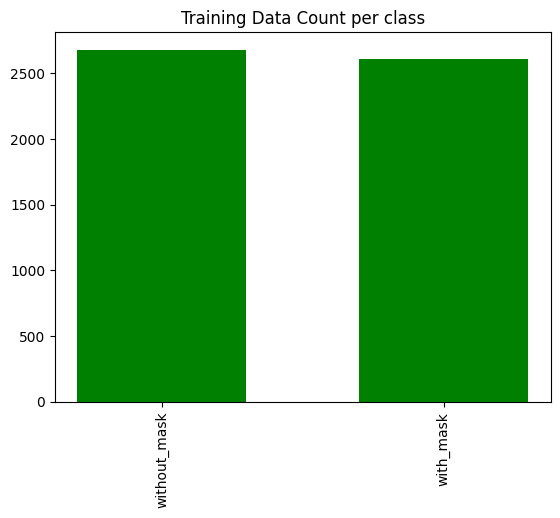

In [30]:
plt.bar(x=count_dict.keys(), height=count_dict.values(), color='green', width=0.6)
plt.xticks(rotation=90)
plt.title("Training Data Count per class")
plt.show()

In [50]:
model = Sequential([

    Conv2D(16, kernel_size=(3,3), padding='same', activation='relu', input_shape=(224,224, 3)),
    Conv2D(16, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, kernel_size=(3,3), activation='relu'),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling2D(),

    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation='sigmoid')

])

In [51]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 54, 54, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,849 (284.57 KB)

 Trainable params: 72,497 (283.19 KB)

 Non-trainable params: 352 (1.38 KB)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_loss',patience=5,restore_best_weights=True)

In [47]:
model.compile(
                    optimizer = tf.keras.optimizers.Adam(learning_rate=0.005),
                    loss = 'binary_crossentropy',

                    metrics = ['accuracy']
                   )

In [48]:
history = model.fit(train_ds, epochs=20, validation_data=val_ds,
                          callbacks = early_stopping,
                          batch_size = 64,
                          verbose=1)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.6879 - loss: 0.8935 - val_accuracy: 0.4954 - val_loss: 2.6312
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 870ms/step - accuracy: 0.7666 - loss: 0.5143 - val_accuracy: 0.6795 - val_loss: 0.7617
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 876ms/step - accuracy: 0.7850 - loss: 0.4780 - val_accuracy: 0.5298 - val_loss: 0.7175
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 872ms/step - accuracy: 0.8312 - loss: 0.3949 - val_accuracy: 0.7735 - val_loss: 0.5053
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 873ms/step - accuracy: 0.8460 - loss: 0.3694 - val_accuracy: 0.7397 - val_loss: 0.5284
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 929ms/step - accuracy: 0.8542 - loss: 0.3488 - val_accuracy: 0.6550 - val_loss: 0.6303
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 36s 862ms/step - accuracy: 0.8687 - loss: 0.3059 - val_accuracy: 0.7464 - val_loss: 0.5530
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 36s 859ms/step - accuracy: 0.8886 - loss: 0.2699 - val_accura

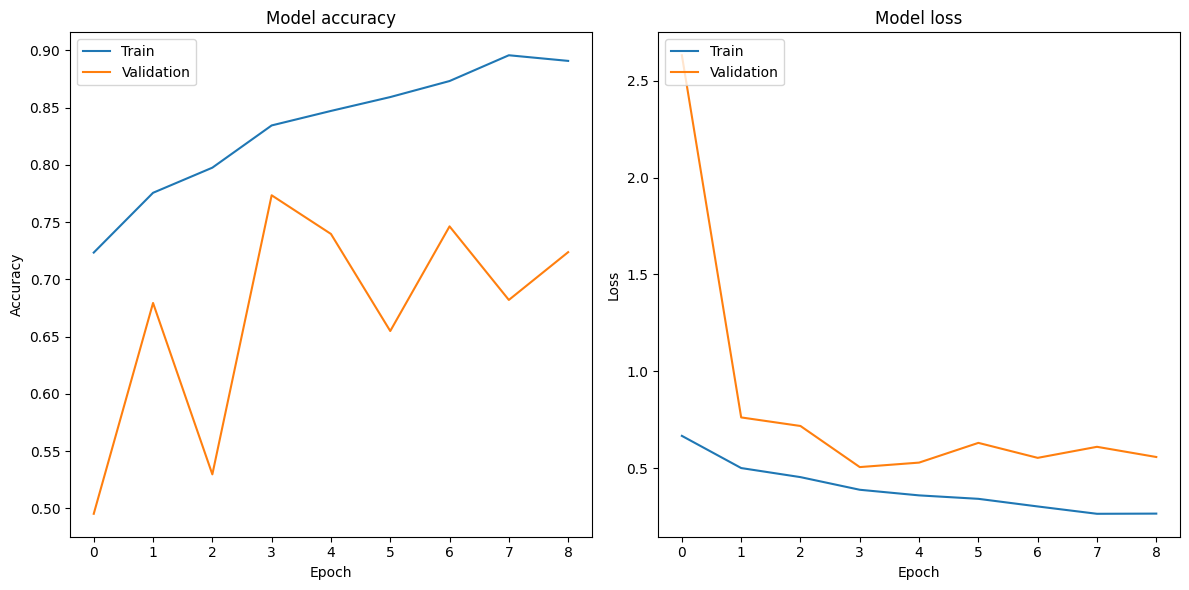

In [49]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()